# Análise de Dados do Dataset Disney

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregando o dataset disney_data.csv
disney = pd.read_csv('disney_data.csv')
disney.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,"November 26, 2021",2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,"November 26, 2021",1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,"November 26, 2021",2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,"November 26, 2021",2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,"November 25, 2021",2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...


In [3]:
disney.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1450 non-null   object
 1   type          1450 non-null   object
 2   title         1450 non-null   object
 3   director      977 non-null    object
 4   cast          1260 non-null   object
 5   country       1231 non-null   object
 6   date_added    1447 non-null   object
 7   release_year  1450 non-null   int64 
 8   rating        1447 non-null   object
 9   duration      1450 non-null   object
 10  listed_in     1450 non-null   object
 11  description   1450 non-null   object
dtypes: int64(1), object(11)
memory usage: 136.1+ KB


In [4]:
disney.describe()

,release_year
count,1450.000000
mean,2003.091724
std,21.860162
min,1928.000000
25%,1999.000000
50%,2011.000000
75%,2018.000000
max,2021.000000


In [5]:
# Valores únicos
disney.nunique()

show_id         1450
type               2
title           1450
director         609
cast            1193
country           89
date_added       167
release_year      90
rating             9
duration         158
listed_in        329
description     1448
dtype: int64

In [6]:
# Valores nulos
disney.isnull().sum()

show_id           0
type              0
title             0
director        473
cast            190
country         219
date_added        3
release_year      0
rating            3
duration          0
listed_in         0
description       0
dtype: int64

In [7]:
# Linhas que têm títulos repetidos
titulos_duplicados = disney[disney.duplicated(subset=['title'], keep=False)]
print(titulos_duplicados.sort_values(by='title'))

Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description]
Index: []


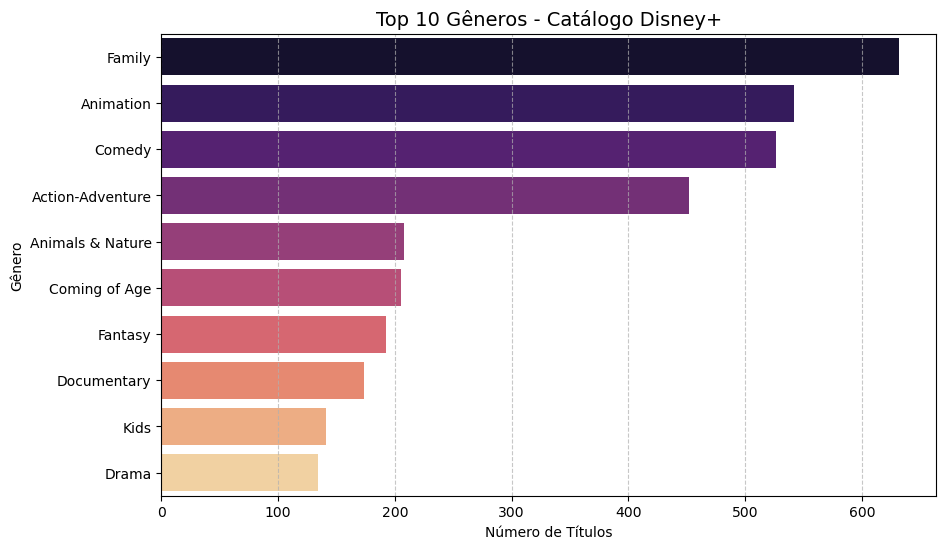

In [14]:
# 1. Tratamento: Explodir a coluna de gêneros (listed_in)
# Isso separa "Ação, Comédia" em linhas individuais
generos_contagem = disney['listed_in'].str.split(', ').explode().value_counts().head(10)

# 2. Criação do Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x=generos_contagem.values, 
    y=generos_contagem.index, 
    hue=generos_contagem.index,  # Atribui o eixo Y ao HUE
    legend=False,                  # Remove a legenda automática
    palette='magma'
)

# 3. Personalização
plt.title('Top 10 Gêneros - Catálogo Disney+', fontsize=14)
plt.xlabel('Número de Títulos')
plt.ylabel('Gênero')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Exibir
plt.show()

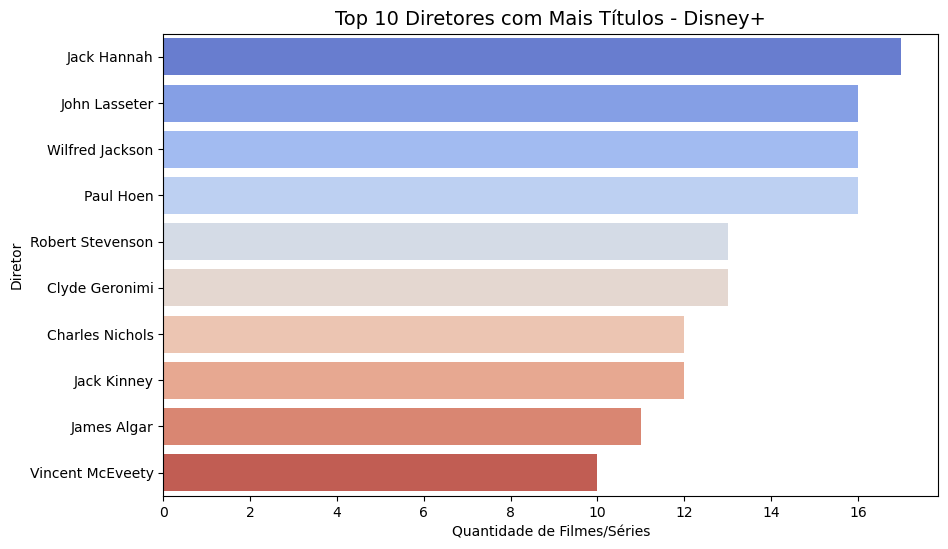

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tratamento
diretores_contagem = disney['director'].dropna().str.split(', ').explode().value_counts().head(10)

# 2. Criação do Gráfico (Ajustado para evitar o aviso/warning)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=diretores_contagem.values, 
    y=diretores_contagem.index, 
    hue=diretores_contagem.index,  # Atribui o eixo Y ao HUE
    legend=False,                  # Remove a legenda automática
    palette='coolwarm'
)

# 3. Personalização
plt.title('Top 10 Diretores com Mais Títulos - Disney+', fontsize=14)
plt.xlabel('Quantidade de Filmes/Séries')
plt.ylabel('Diretor')

plt.show()



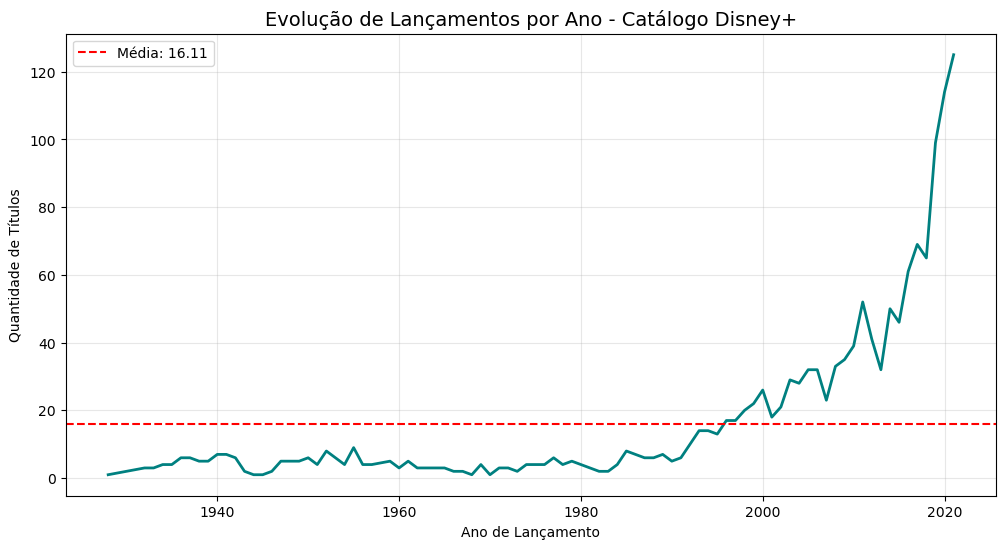

In [16]:
# 1. Agrupar por ano e contar a quantidade de títulos
evolucao_temporal = disney['release_year'].value_counts().sort_index()

# 2. Calcular a média anual de lançamentos (para o insight)
media_lancamentos = evolucao_temporal.mean()

# 3. Criar o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(x=evolucao_temporal.index, y=evolucao_temporal.values, color='teal', linewidth=2)

# 4. Adicionar uma linha tracejada com a média
plt.axhline(media_lancamentos, color='red', linestyle='--', label=f'Média: {media_lancamentos:.2f}')

# 5. Personalização
plt.title('Evolução de Lançamentos por Ano - Catálogo Disney+', fontsize=14)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade de Títulos')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()